In [1]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Step 1: Load Dataset
DATASET_PATH = '/kaggle/input/insurance/insurance.csv'
insurance = pd.read_csv(DATASET_PATH)

# Display basic dataset information
print("Dataset Overview:")
print(insurance.info())
print(insurance.head())

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [2]:

# Step 2: Preprocess Dataset
# Encode categorical variables and map binary variables
categorical_cols = ['sex', 'region']
insurance = pd.get_dummies(insurance, columns=categorical_cols, drop_first=True)
insurance['smoker'] = insurance['smoker'].map({'yes': 1, 'no': 0})

# Split the dataset into training and testing sets
train_df = insurance.sample(frac=0.8, random_state=42)
test_df = insurance.drop(train_df.index)

X_train = train_df.drop(columns=['charges'])
y_train = train_df['charges']
X_test = test_df.drop(columns=['charges'])
y_test = test_df['charges']

In [3]:
# Step 3: Define Function for Single Predictor Analysis
def single_predictor_analysis(predictor, X_train, y_train, X_test, y_test):
    """
    Perform linear regression using a single predictor and return model metrics.
    """
    model = LinearRegression()
    model.fit(X_train[[predictor]], y_train)
    y_pred = model.predict(X_test[[predictor]])

    # Model Metrics
    intercept = model.intercept_
    coefficient = model.coef_[0]
    RSS = np.sum((y_test - y_pred) ** 2)
    RSE = np.sqrt(RSS / (len(y_test) - 2))
    r_squared = r2_score(y_test, y_pred)

    # Statistical Summary using OLS
    X_with_const = sm.add_constant(X_train[[predictor]])
    ols_model = sm.OLS(y_train, X_with_const).fit()
    conf_int = ols_model.conf_int(alpha=0.05)
    se = ols_model.bse
    t_values = ols_model.tvalues
    p_values = ols_model.pvalues

    return {
        'intercept': intercept,
        'coefficient': coefficient,
        'RSS': RSS,
        'RSE': RSE,
        'r_squared': r_squared,
        'conf_int': conf_int,
        'se': se,
        't_values': t_values,
        'p_values': p_values
    }, y_pred


In [4]:

# Step 4: Analyze Single Predictors
# BMI Predictor Analysis
bmi_results, y_pred_bmi = single_predictor_analysis('bmi', X_train, y_train, X_test, y_test)

# Smoker Predictor Analysis
smoker_results, y_pred_smoker = single_predictor_analysis('smoker', X_train, y_train, X_test, y_test)


In [5]:

# Step 5: Multiple Linear Regression
def multiple_linear_regression(X_train, y_train, X_test, y_test):
    """
    Perform multiple linear regression and return model metrics.
    """
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r_squared = r2_score(y_test, y_pred)
    RSE = np.sqrt(mean_squared_error(y_test, y_pred))

    return model, y_pred, r_squared, RSE

model_multi, y_pred_multi, r_squared_multi, RSE_multi = multiple_linear_regression(X_train, y_train, X_test, y_test)


In [6]:
# Step 6: Interaction Effects
# Example: Interaction between BMI and Smoker
insurance['bmi_smoker'] = insurance['bmi'] * insurance['smoker']
X_train_interaction = X_train.copy()
X_train_interaction['bmi_smoker'] = X_train['bmi'] * X_train['smoker']
X_test_interaction = X_test.copy()
X_test_interaction['bmi_smoker'] = X_test['bmi'] * X_test['smoker']
interaction_model = sm.OLS(y_train, sm.add_constant(X_train_interaction[['bmi', 'smoker', 'bmi_smoker']])).fit()

# Step 7: Non-linear Effects
# Example: Quadratic term for BMI
insurance['bmi_squared'] = insurance['bmi'] ** 2
X_train_nonlinear = X_train.copy()
X_train_nonlinear['bmi_squared'] = X_train['bmi'] ** 2
X_test_nonlinear = X_test.copy()
X_test_nonlinear['bmi_squared'] = X_test['bmi'] ** 2
nonlinear_model = sm.OLS(y_train, sm.add_constant(X_train_nonlinear[['bmi', 'bmi_squared']])).fit()


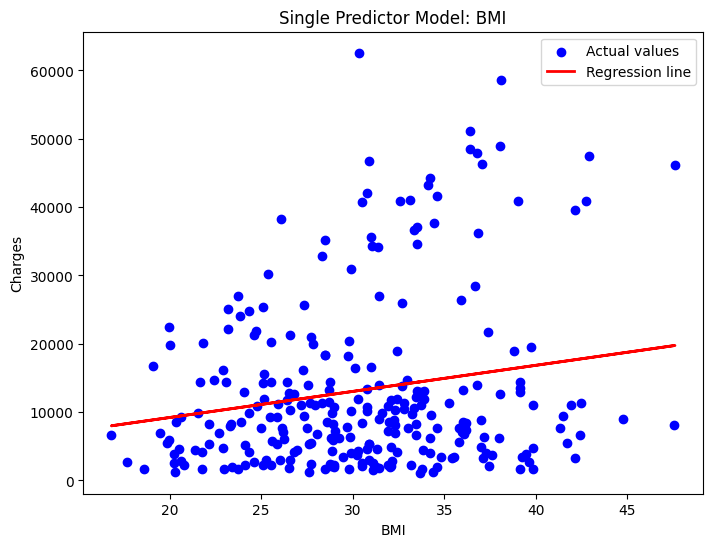

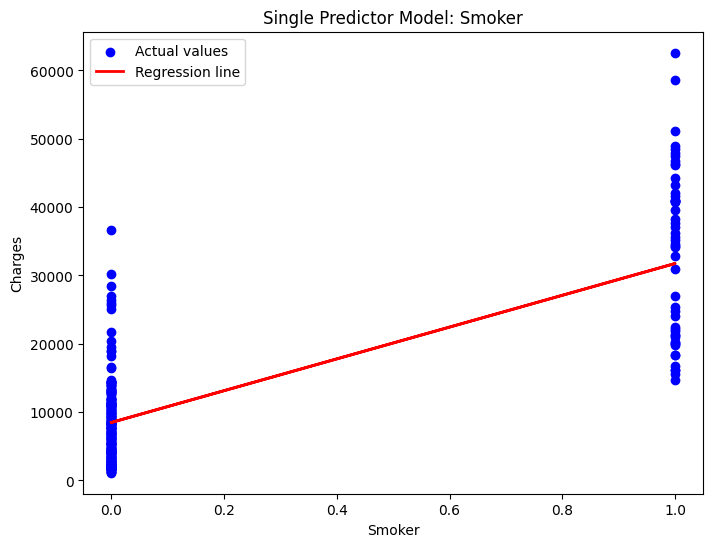

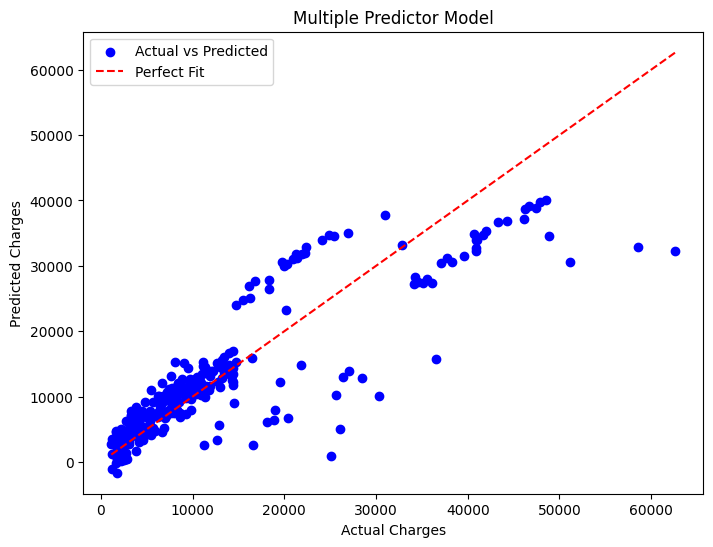

In [7]:
# Step 8: Visualization
def plot_regression_results(x, y, y_pred, x_label, y_label, title):
    """
    Plot regression results with actual and predicted values.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color='blue', label='Actual values')
    plt.plot(x, y_pred, color='red', linewidth=2, label='Regression line')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend()
    plt.show()

# Visualize BMI Predictor Results
plot_regression_results(X_test['bmi'], y_test, y_pred_bmi, 'BMI', 'Charges', 'Single Predictor Model: BMI')

# Visualize Smoker Predictor Results
plot_regression_results(X_test['smoker'], y_test, y_pred_smoker, 'Smoker', 'Charges', 'Single Predictor Model: Smoker')

# Visualize Multiple Predictor Results
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_multi, color='blue', label='Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Fit')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Multiple Predictor Model')
plt.legend()
plt.show()

In [9]:
# Summarize Multiple Linear Regression Results
print("\nMultiple Linear Regression Model Results:")
print(f"R-squared: {r_squared_multi:.4f}")
print(f"RSE: {RSE_multi:.4f}")

# Summarize Interaction Model
print("\nInteraction Model Results:")
print(interaction_model.summary())

# Summarize Non-linear Model
print("\nNon-linear Model Results:")
print(nonlinear_model.summary())


Multiple Linear Regression Model Results:
R-squared: 0.7513
RSE: 6230.4624

Interaction Model Results:
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     1024.
Date:                Mon, 03 Mar 2025   Prob (F-statistic):          2.26e-313
Time:                        19:17:03   Log-Likelihood:                -10843.
No. Observations:                1070   AIC:                         2.169e+04
Df Residuals:                    1066   BIC:                         2.171e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

# 1) Apply Resampling method to your regression

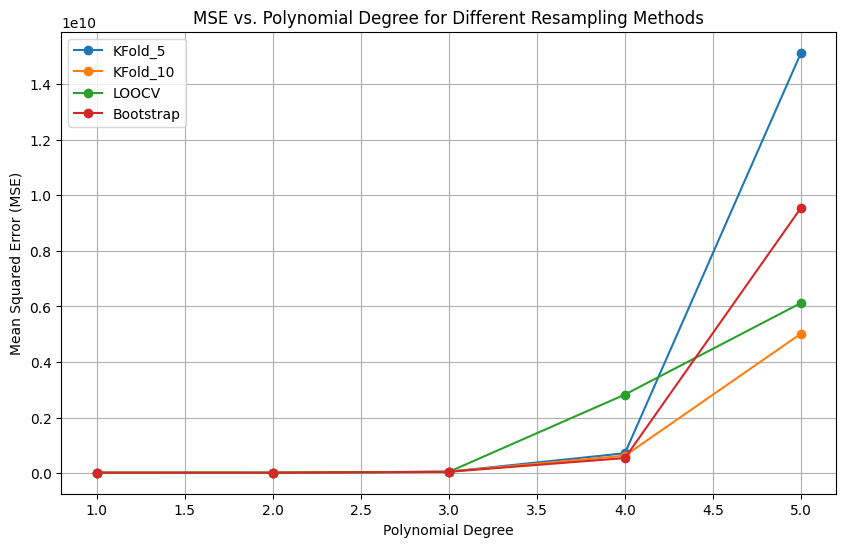

In [21]:
max_degree = 5
decreed_list = list(range(1, max_degree + 1))
mse_results = {"KFold_5": [], "KFold_10": [], "LOOCV": [], "Bootstrap": []}

for degree in decreed_list:
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(X)

# a) KFold MSE and loocv
    
    for k in [5, 10]:
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        mse = -cross_val_score(LinearRegression(), X_poly, y, cv=kf, scoring='neg_mean_squared_error').mean()
        mse_results[f"KFold_{k}"].append(mse)

    loocv = LeaveOneOut()
    mse_results["LOOCV"].append(-cross_val_score(LinearRegression(), X_poly, y, cv=5, scoring='neg_mean_squared_error').mean())  

 # b) Bootstrap MSE
    bootstrap_mses = []
    for _ in range(100):  
        X_resample, y_resample = resample(X_poly, y, random_state=42)
        model = LinearRegression().fit(X_resample, y_resample)
        y_pred = model.predict(X_poly)
        bootstrap_mses.append(mean_squared_error(y, y_pred))
    mse_results["Bootstrap"].append(np.mean(bootstrap_mses))

#  c) Plot MSE vs Polynomial Degree
plt.figure(figsize=(10, 6))
for method, mse_values in mse_results.items():
    plt.plot(decreed_list, mse_values, marker='o', label=method)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("MSE vs. Polynomial Degree for Different Resampling Methods")
plt.legend()
plt.grid(True)
plt.show()


# 2) Apply model selection method for your regression 

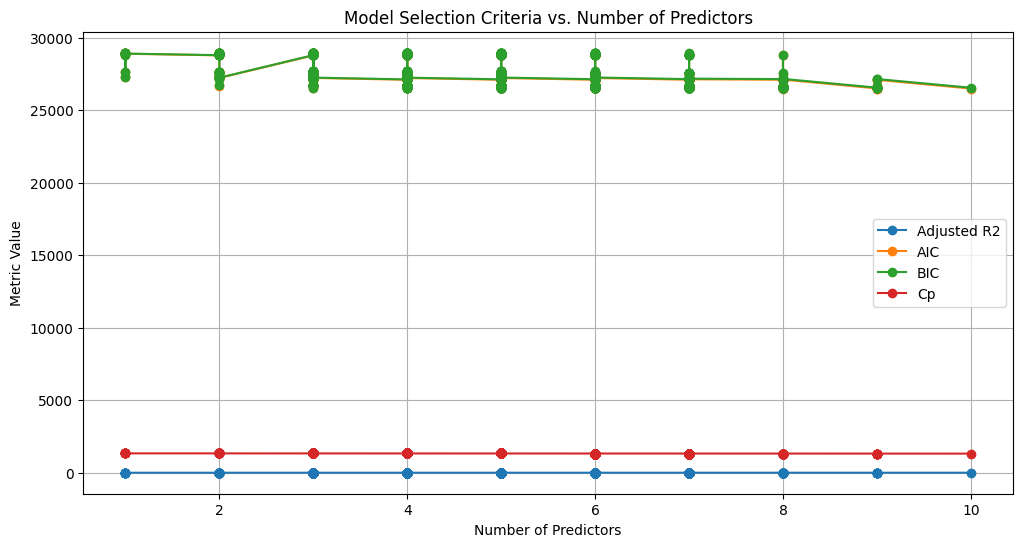

In [20]:
from itertools import combinations
import statsmodels.api as sm
import pandas as pd


# a)  Cp, AIC, BIC, Adjusted R2 and cross validation methods
def best_subset_selection(X, y):
    predictors = X.columns.tolist()
    num_predictors = len(predictors)
    results = []

    for k in range(1, num_predictors + 1):
        for subset in combinations(predictors, k):
            X_subset = X[list(subset)]
            X_subset = sm.add_constant(X_subset)  
            model = sm.OLS(y, X_subset).fit()
            
            rss = ((model.resid) ** 2).sum()
            mse = rss / model.df_resid
            aic = model.aic
            bic = model.bic
            adj_r2 = model.rsquared_adj
            cp = rss / mse - (len(subset) + 1 - 2)  # Mallows' Cp approximation
            
            results.append((k, subset, model.rsquared, adj_r2, aic, bic, cp))

    results_df = pd.DataFrame(results, columns=['Num Predictors', 'Subset', 'R2', 'Adjusted R2', 'AIC', 'BIC', 'Cp'])
    return results_df



X = pd.get_dummies(insurance.drop(columns=['charges']), drop_first=True)
X = X.astype(float)
y = insurance['charges']

subset_results = best_subset_selection(X, y)

plt.figure(figsize=(12, 6))
metrics = ['Adjusted R2', 'AIC', 'BIC', 'Cp']
for metric in metrics:
    plt.plot(subset_results['Num Predictors'], subset_results[metric], marker='o', label=metric)

plt.xlabel("Number of Predictors")
plt.ylabel("Metric Value")
plt.title("Model Selection Criteria vs. Number of Predictors")
plt.legend()
plt.grid(True)
plt.show()


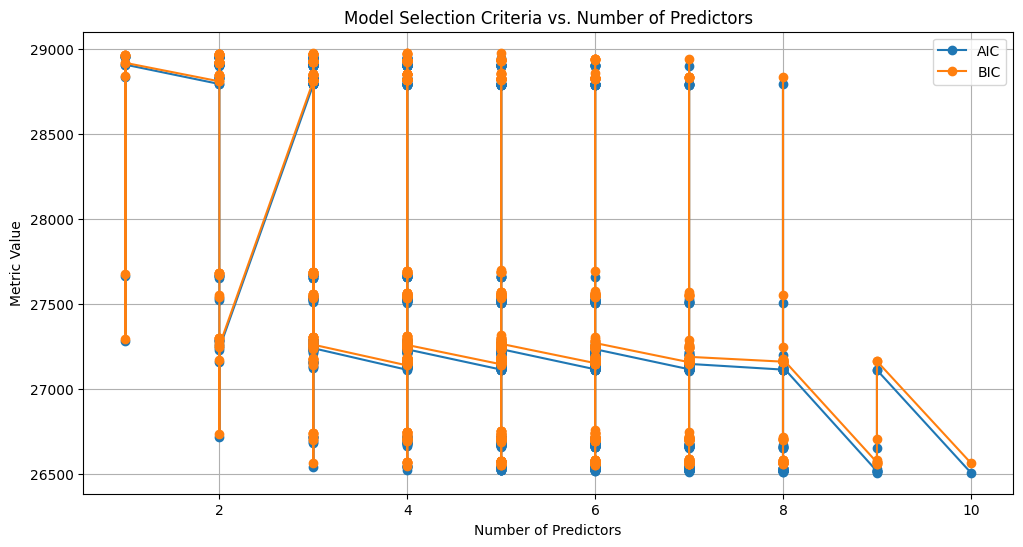

In [24]:

plt.figure(figsize=(12, 6))
metrics = ['AIC', "BIC"]
for metric in metrics:
    plt.plot(subset_results['Num Predictors'], subset_results[metric], marker='o', label=metric)

plt.xlabel("Number of Predictors")
plt.ylabel("Metric Value")
plt.title("Model Selection Criteria vs. Number of Predictors")
plt.legend()
plt.grid(True)
plt.show()

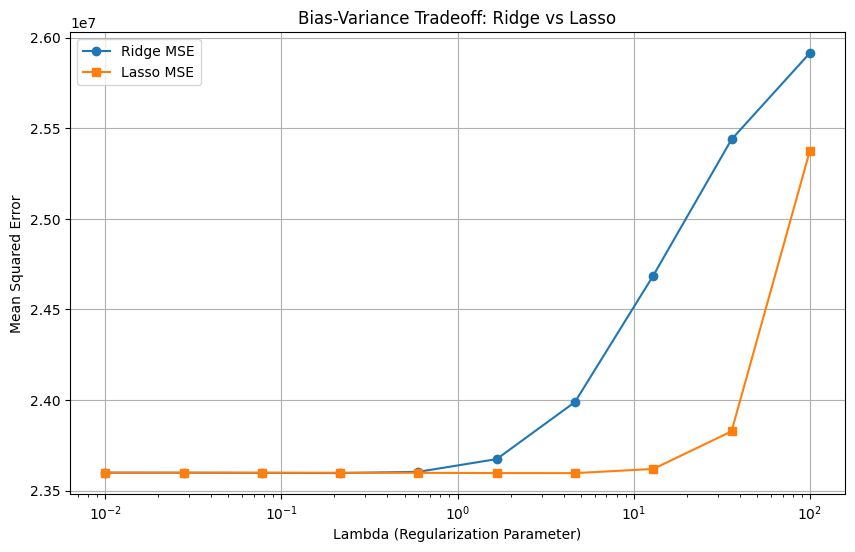

In [15]:
from itertools import combinations
import statsmodels.api as sm
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
import numpy as np


# b) Shrinkage Methods: Ridge and Lasso Regression
alphas = np.logspace(-2, 2, 10)  # Reduced range for faster computation
ridge_mse = []
lasso_mse = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge_mse.append(-cross_val_score(ridge, X, y, cv=5, scoring='neg_mean_squared_error').mean())  # Reduced cv to 5
    
    lasso = Lasso(alpha=alpha, max_iter=5000)
    lasso_mse.append(-cross_val_score(lasso, X, y, cv=5, scoring='neg_mean_squared_error').mean())

# Plot Bias-Variance Tradeoff
plt.figure(figsize=(10, 6))
plt.plot(alphas, ridge_mse, label='Ridge MSE', marker='o')
plt.plot(alphas, lasso_mse, label='Lasso MSE', marker='s')
plt.xscale('log')
plt.xlabel("Lambda (Regularization Parameter)")
plt.ylabel("Mean Squared Error")
plt.title("Bias-Variance Tradeoff: Ridge vs Lasso")
plt.legend()
plt.grid(True)
plt.show()



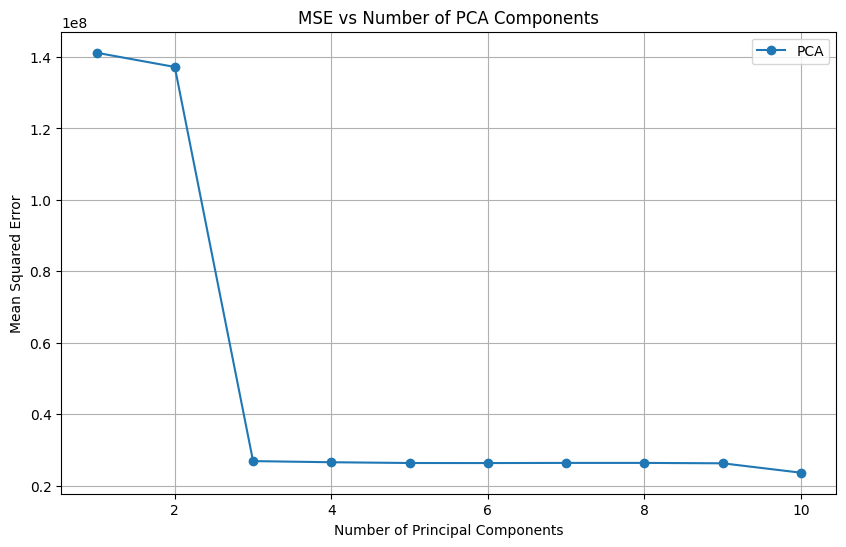

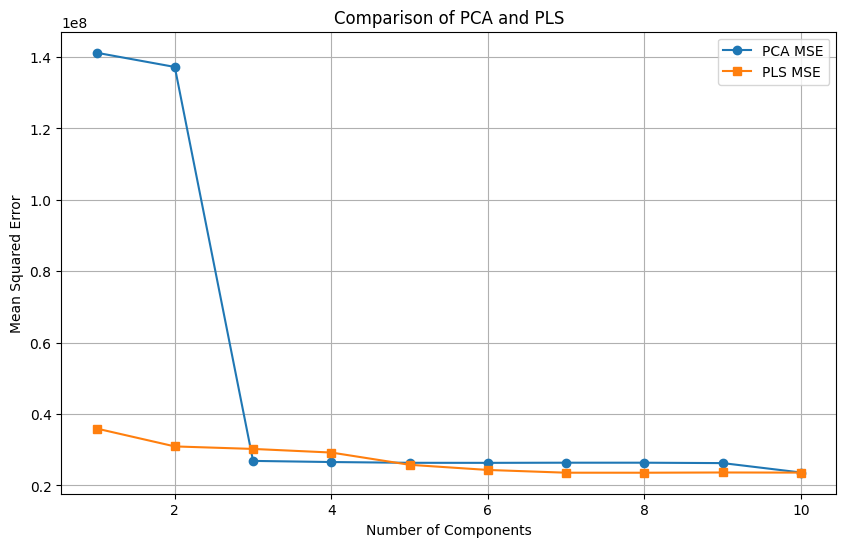

In [16]:
# c) PCA and PLS

#PCA for Dimensionality Reduction
mse_pca = []
n_components_range = range(1, X.shape[1] + 1)
for n in n_components_range:
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X)
    mse = -cross_val_score(Ridge(alpha=1), X_pca, y, cv=5, scoring='neg_mean_squared_error').mean()
    mse_pca.append(mse)

# Plot MSE vs Number of PCA Components
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, mse_pca, marker='o', label='PCA')
plt.xlabel("Number of Principal Components")
plt.ylabel("Mean Squared Error")
plt.title("MSE vs Number of PCA Components")
plt.legend()
plt.grid(True)
plt.show()

# Partial Least Squares (PLS)
mse_pls = []
for n in n_components_range:
    pls = PLSRegression(n_components=n)
    mse = -cross_val_score(pls, X, y, cv=5, scoring='neg_mean_squared_error').mean()
    mse_pls.append(mse)

# Comparing plots
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, mse_pca, marker='o', label='PCA MSE')
plt.plot(n_components_range, mse_pls, marker='s', label='PLS MSE')
plt.xlabel("Number of Components")
plt.ylabel("Mean Squared Error")
plt.title("Comparison of PCA and PLS")
plt.legend()
plt.grid(True)
plt.show()
